## 1. A localized function in real space

Dada la función:

\begin{equation}
    f(x) =
    \begin{cases}
        1, & 3 < x < 4,\\
        0, & \text{otherwise},
    \end{cases}
\end{equation}

1. Sí, la función $f(x)$ es una función localizada en el intervalo $(3, 4)$.
2. No, debido a que $f(x)$ posee distontinuidades en los puntos $3$ y $4$.
3. La transformada de Fourier es una transformada integral que hace el cambio entre espacios mediante un *kernel* que depende del producto de los modos y las coordenadas, $\vec{k}\cdot\vec{x}$. En este caso, como solo estoy en una dimensión, entonces solo espero un modo de Fourier.
4. La integral va a soltar algunas costantes, en particular un $-i$. La magnitud puede va a variar dependiendo de cómo sea la definición de la transformada, pero va a ser constante, por lo tanto yo espero una línea recta horizontal en la parte negativa de las ordenadas.

![](./amplitud.png)

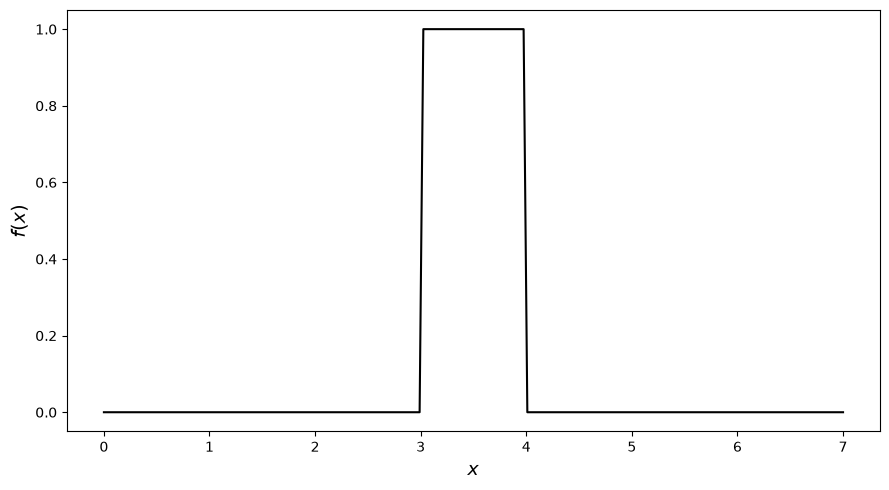

In [240]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, l = 3, r = 4):
    if l < x and x < r:
        return 1
    else:
        return 0

N = 200
x_arr = np.linspace(0, 7, N)
f_arr = np.array([f(x) for x in x_arr])

plt.figure(figsize=(9, 5))
plt.plot(x_arr, f_arr, "k-", lw=1.5, label=r"$f(x)$")
plt.xlabel(r"$x$", fontsize=14)
plt.ylabel(r"$f(x)$", fontsize=14)
#plt.legend()
plt.tight_layout()
plt.show()

## 2. From real to Fourier space

In [241]:
dx = np.full(N, 7 / N)
f_fourier_arr = np.fft.fft(f_arr)
k_arr = np.fft.fftfreq(N, d=dx)

abs_k_arr = np.abs(k_arr)

k_min = np.min(abs_k_arr[abs_k_arr != 0])
k_min_index = np.argmax(abs_k_arr == k_min)

k_max = np.max(abs_k_arr)
k_max_index = np.argmax(abs_k_arr == k_max)

print(f"El espaciado entre modos es: {k_arr[1] - k_arr[0]:.4f}.")
print(f"La frecuencia mínima es: {k_min:.4f}, id: {k_min_index}.")
print(f"La frecuencia máxima es: {k_max:.4f}, id: {k_max_index}.")


El espaciado entre modos es: 0.1429.
La frecuencia mínima es: 0.1429, id: 1.
La frecuencia máxima es: 14.2857, id: 100.


1. <details><summary>Primero las positivas, luego las negativas.</summary> Si existen positivos y negativos, entonces deben existir determinados puntos donde se cruza el cero. Se puede analizar el signo de la primer entrada distinta de cero y encontrar todos aquellos cambios de signo con un único recorrido del <i>array</i> para obtener el orden de positivos y negativos. Resultando en que primero es positivo, luego toca el cero, continua positivo y, en algún momento, cruza el cero hacia los negativos.</details>
2. La frecuencia más pequeña disinta de cero es: $k = 0.1429$ y está en la posición $1$ del *array*.
3. La frecuencia más grande representada por el *grid* es: $|k| = 14.2857$ y está en la posición $100$ del *array*.
4. Quiero pensar que, al igual que $\Delta x$, $\Delta k$ representa el espaciado del *grid* elegido, en este caso representa el muestro de las frecuencias elegidas para representar a la función original con frecuencias de Fourier.
5. Determina el centro de la función y del espacio.


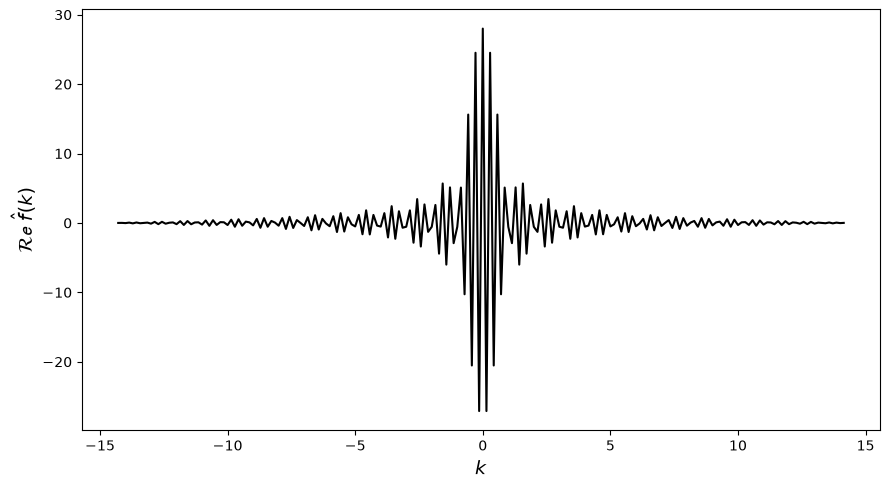

In [242]:
k_arr_shifted = np.fft.fftshift(k_arr)
f_fourier_arr_shifted = np.fft.fftshift(f_fourier_arr)

plt.figure(figsize=(9, 5))
plt.plot(k_arr_shifted, f_fourier_arr_shifted, "k-", lw=1.5, label=r"$Absolute$")
plt.xlabel(r"$k$", fontsize=14)
plt.ylabel(r"$\mathcal{Re}\ \hat f(k)$", fontsize=14)
#plt.legend()
plt.tight_layout()
plt.show()

## 3. The Fourier transform of a top-hat



/tmp/ipykernel_8962/4264452597.py:4: RuntimeWarning: invalid value encountered in divide
  return n / d


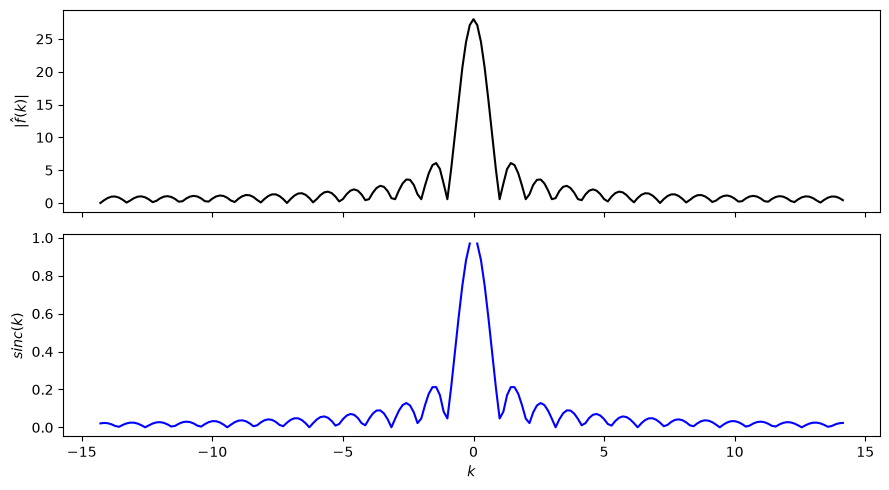

In [243]:
def sinc(k, D = 1):
    n = np.sin(k * D / 2)
    d = k * D / 2
    return n / d

envelop_arr = sinc(k_arr_shifted, 6)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(9, 5))
ax1.plot(k_arr_shifted, np.abs(f_fourier_arr_shifted), "k-", lw=1.5, label=r"$Fourier trans.$")
ax2.plot(k_arr_shifted, np.abs(envelop_arr), "b-", lw=1.5, label=r"$sinc-like envelope$")
ax1.set_ylabel(r"$|\hat f(k)|$")
ax2.set(xlabel=r"$k$", ylabel=r"$sinc(k)$")
fig.tight_layout()
plt.show()

1. Sí, las oscilaciones sí se ven claramente.
2. Para representar las discontinuidades del *top-hat*, se necesitan altas frecuencias, estas nuevas frecuencias no necesariamente deben corresponder al dominio de la función original.
3. Lo que le ocurre es que los picos se van separado entre si y las amplitudes bajan. Si la transformada fuera una cuerda, el cambio debido al cambio del *top-hat* sería equivalente a tomar la cuerda por los extremos e irla estirando en direcciones opuestas.
4. Lo contrario, que los picos se acerquen más entre ellos y que las amplitudes crezcan.

## 4. Amplitude and phase



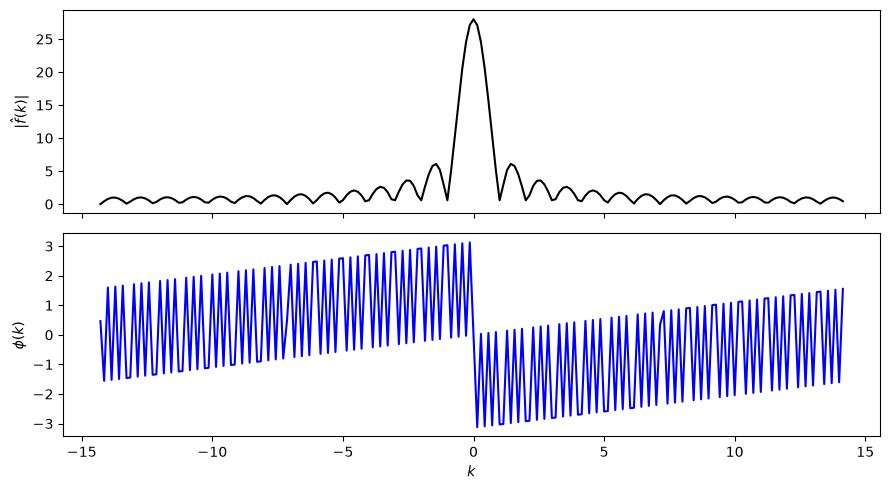

In [244]:
phase_arr = np.angle(f_fourier_arr_shifted)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(9, 5))
ax1.plot(k_arr_shifted, np.abs(f_fourier_arr_shifted), "k-", lw=1.5, label=r"$Fourier trans.$")
ax2.plot(k_arr_shifted, phase_arr, "b-", lw=1.5, label=r"$Phase$")
ax1.set_ylabel(r"$|\hat f(k)|$")
ax2.set(xlabel=r"$k$", ylabel=r"$\phi(k)$")
fig.tight_layout()
plt.show()

1. <details><summary>Las amplitudes no van a cambiar.</summary>Entendiendo la transformada de Fourier como el caso continuo de las series de Fourier, entonces cada $k$ representa una frecuencia de un armónico y se ocupan los mismo armónicos para representar la misma forma de las funciones, en este caso $f(x)$.</details>
2. Las frecuencias sí van a cambiar para cambiar el punto de inicio de la descripción.

Sea $f_{12}(x)$ la función $f(x)$ desplazada al intervalo $1 < f_{12}(x) < 2$ en el mismo dominio, entonces:

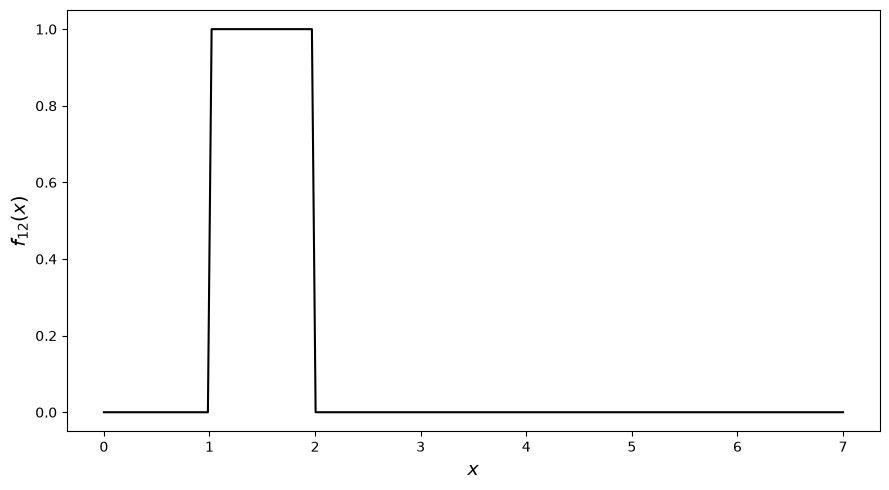

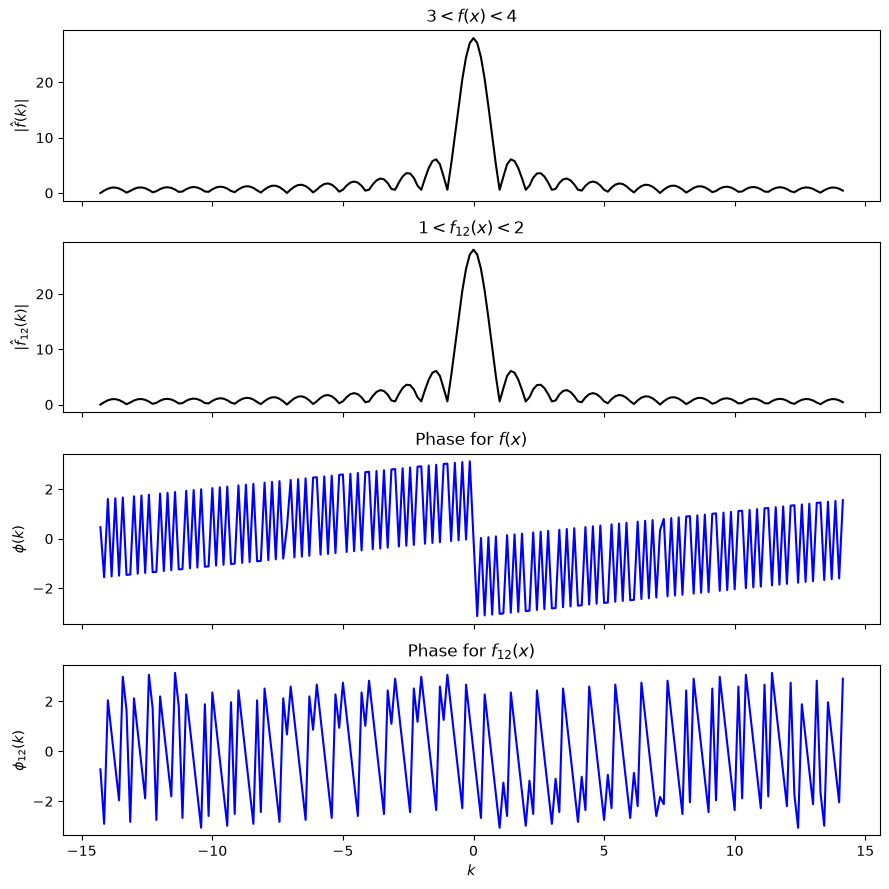

In [245]:
f12_arr = np.array([f(x, l=1, r=2) for x in x_arr])

plt.figure(figsize=(9, 5))
plt.plot(x_arr, f12_arr, "k-", lw=1.5, label=r"$f(x)$")
plt.xlabel(r"$x$", fontsize=14)
plt.ylabel(r"$f_{12}(x)$", fontsize=14)
#plt.legend()
plt.tight_layout()
plt.show()

k12_arr = np.fft.fftfreq(N, d=dx)
f12_fourier_arr = np.fft.fft(f12_arr)

k12_arr_shifted = np.fft.fftshift(k12_arr)
f12_fourier_arr_shifted = np.fft.fftshift(f12_fourier_arr)
phase12_arr = np.angle(f12_fourier_arr_shifted)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, sharex=True, figsize=(9, 9))
ax1.plot(k_arr_shifted, np.abs(f_fourier_arr_shifted), "k-")
ax2.plot(k12_arr_shifted, np.abs(f12_fourier_arr_shifted), "k-")
ax3.plot(k_arr_shifted, phase_arr, "b-")
ax4.plot(k12_arr_shifted, phase12_arr, "b-")
ax1.set_title(r"$3 < f(x) < 4$")
ax2.set_title(r"$1 < f_{12}(x) < 2$")
ax3.set_title(r"Phase for $f(x)$")
ax4.set_title(r"Phase for $f_{12}(x)$")
ax1.set_ylabel(r"$|\hat f(k)|$")
ax2.set_ylabel(r"$|\hat f_{12}(k)|$")
ax3.set_ylabel(r"$\phi(k)$")
ax4.set(xlabel=r"$k$", ylabel=r"$\phi_{12}(k)$")
fig.tight_layout()
plt.show()

Puedo decir más acerca de las fases y es que, para la función original,en la distribución de fases se distinguen dos repeticiones de la misma estructura. Esto debe deberse a la simetría del sistema, pues 3.5 es el centro del dominio. Al mover el centro de la gráfica a 1.5, entonces la gráfica de fases que corresponde se ve también diferente.

## 5. Returning to real space

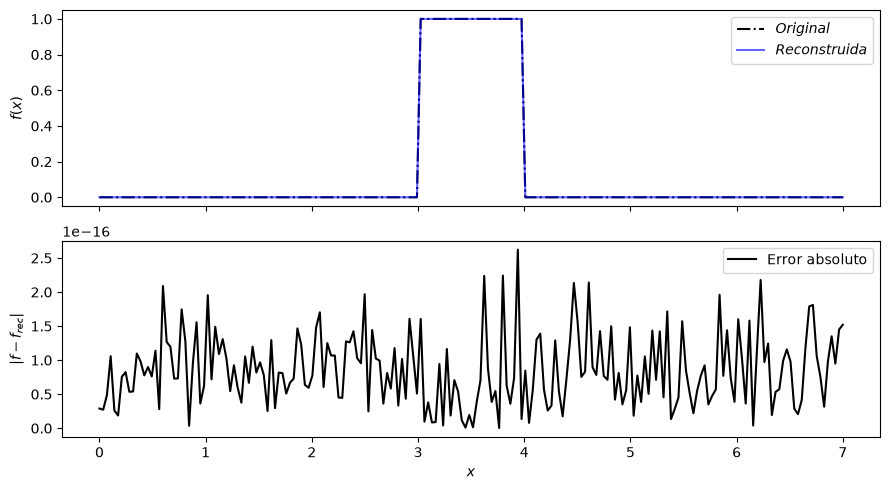

La parte imaginaria es ruido porque su máximo es: 2.09e-16


In [246]:
f_inv_fourier_arr = np.fft.ifft(f_fourier_arr)
err_arr = np.abs(f_arr - f_inv_fourier_arr)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(9, 5))
fig.subplots_adjust(hspace=0)
ax1.plot(x_arr, f_arr, "k-.", lw=1.5, label=r"$Original$")
ax1.plot(x_arr, f_inv_fourier_arr, "b-", alpha=0.6, lw=1.5, label=r"$Reconstruida$")
ax1.set_ylabel(r"$f(x)$")
ax1.legend()
ax2.plot(x_arr, err_arr, "k-", lw=1.5, label="Error absoluto")
ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$|f - f_{rec}|$")
ax2.legend()
fig.tight_layout()
plt.show()

print(f"La parte imaginaria es ruido porque su máximo es: {np.abs(f_inv_fourier_arr.imag).max():.2e}")

1. Sí, son la misma función debido a que el error absoluto máximo que se alcanza con la transformación es menor a $10^{-16}$.
2. Sí, contiene componentes imaginarias residuales.
3. Hay 16 ordenes de magnitud entre unas y otras, por lo que se puede decir que las componentes imaginarias son despreciables por ser ruido numérico.

## 6. The role of sampling

No es necesario copiar y pegar todo con distintos $N$, tampoco encapsular todo en una función para distintos $N$, con cambiar manualmente el valor e investigar tu comportamiento me parece que es suficiente.

### Predicciones:

1. No, no me espero que las frecuencias cambien por el mismo argumento que antes: las frecuencias determinan la forma, ante una modificación que no cambia la forma, no debe cambiar las frecuencias.
2. No, tampoco espero que cambie el dominio de las frecuencias.
3. Sí, la resolución sí debe cambiar, con un bajo $N$ espero ver trapezoides, con un alto $N$ espero ver un *top-hat* bien definido.

Dejando fijo $N$:

1. Quiero pensar que también se van a separar, pero de esto no estoy seguro.
2. Debe incrementar para ajustar al nuevo tamaño de la forma de la función.

### Resultados: 

1. Sí han cambiado las amplitudes.
2. También cambiaron las frecuencias máximas.
3. Sí, esto cambia porque se representan mejor las discontinuidades.

Dejando fijo $N$:

1. No ha cambiado, se ha quedado igual.
2. La frecuencia mínima no cambia.

La función que cumplen $L$ y $\Delta x$ son: 